In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

# Load Data Set 

In [96]:
# Creating the connection
conn = sqlite3.connect('inventory.db')


# Fetching vendor summary data 
df = pd.read_sql_query(""" SELECT * FROM vendor_sales_summary""", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,ExciseTax,FreightCost,GrossProfit,ProfitMargin,SalesTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis


- In the previous step we reviewed the database schema and table relationships to identify candidate variables and the tables to join for the final dataset.  
- In this EDA phase we will profile the resulting joined table column-by-column to quantify distributions, detect outliers and invalid values, and measure data quality (missingness, duplicates, type mismatches, and inconsistent categories).  
- Outputs will include: summary statistics by column (count, mean/median, IQR, min/max), frequency tables for categorical fields, datetime range checks, missing-value and duplicate reports, and a prioritized list of anomalies requiring remediation before modelling or reporting.  
- Acceptance criteria for moving forward: no critical data-type mismatches, all high-impact missing values either explained or imputed with documented rationale, and key outliers validated or flagged for exclusion.


In [97]:
# Summary Statistics 
df.describe().T


,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10514.0,3129.583317,11037.801407,1.000000,36.000000,280.000000,1985.000000,3.349390e+05
TotalSalesDollars,10514.0,42954.173834,168977.755843,1.980000,809.820000,5599.700000,29524.250000,5.101920e+06
TotalSalesPrice,10514.0,19111.958773,45264.605387,0.990000,334.890000,3020.085000,16442.477500,6.728193e+05


<function matplotlib.pyplot.show(close=None, block=None)>

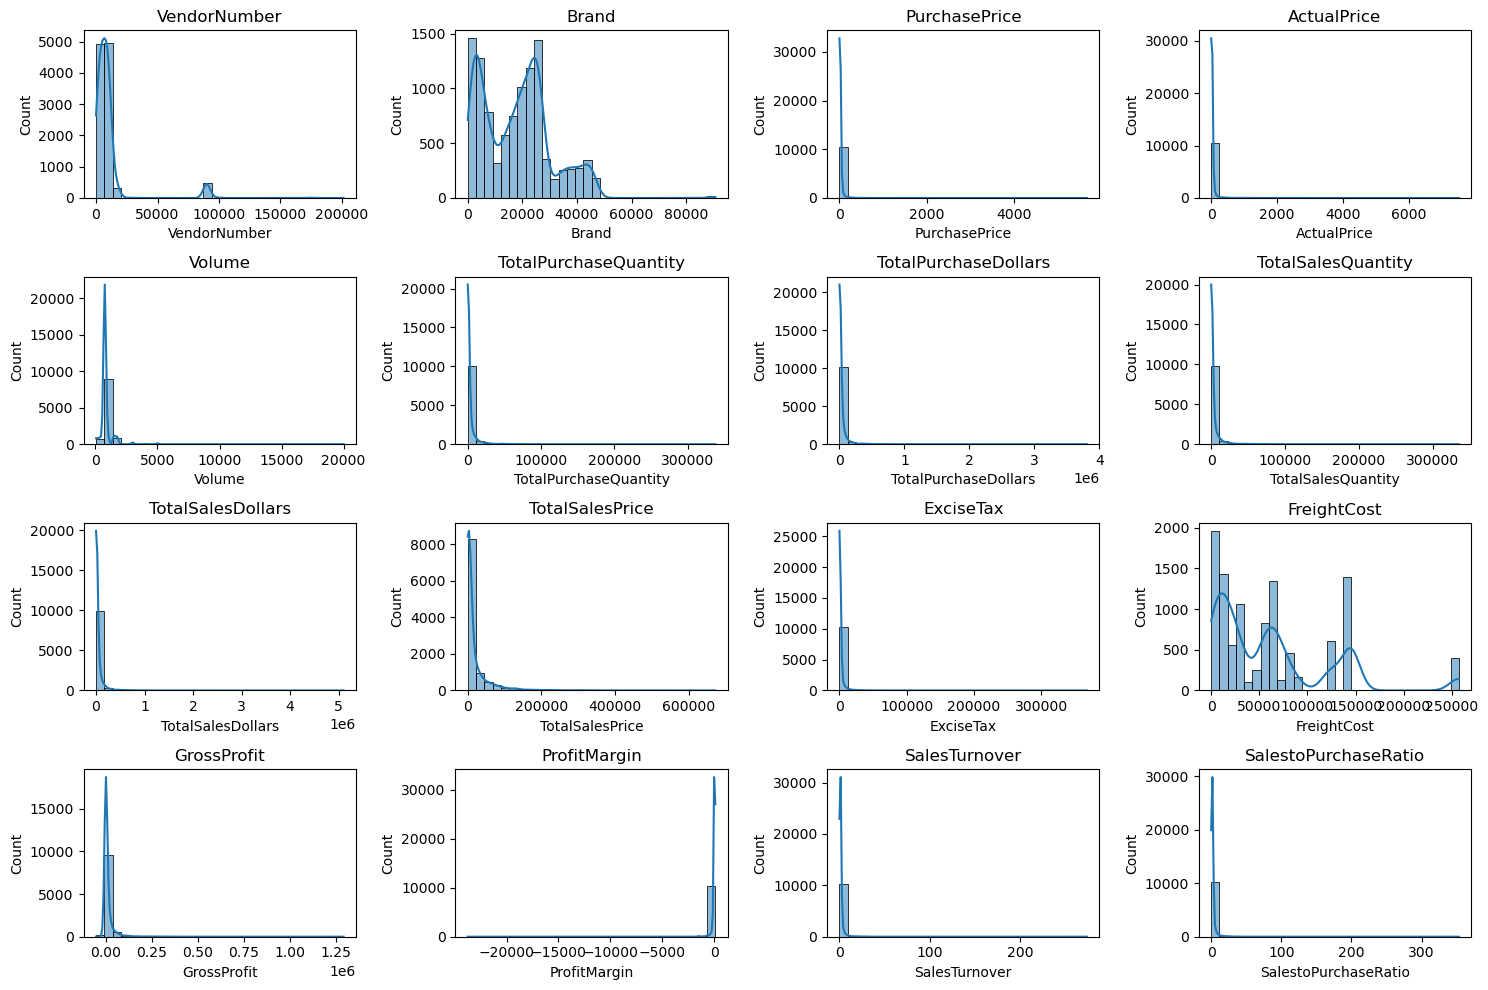

In [98]:
# Distribution Columns for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)   # Adjust layout as needed
    sns.histplot(df[col],kde=True , bins=30)
    plt.title(col)
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

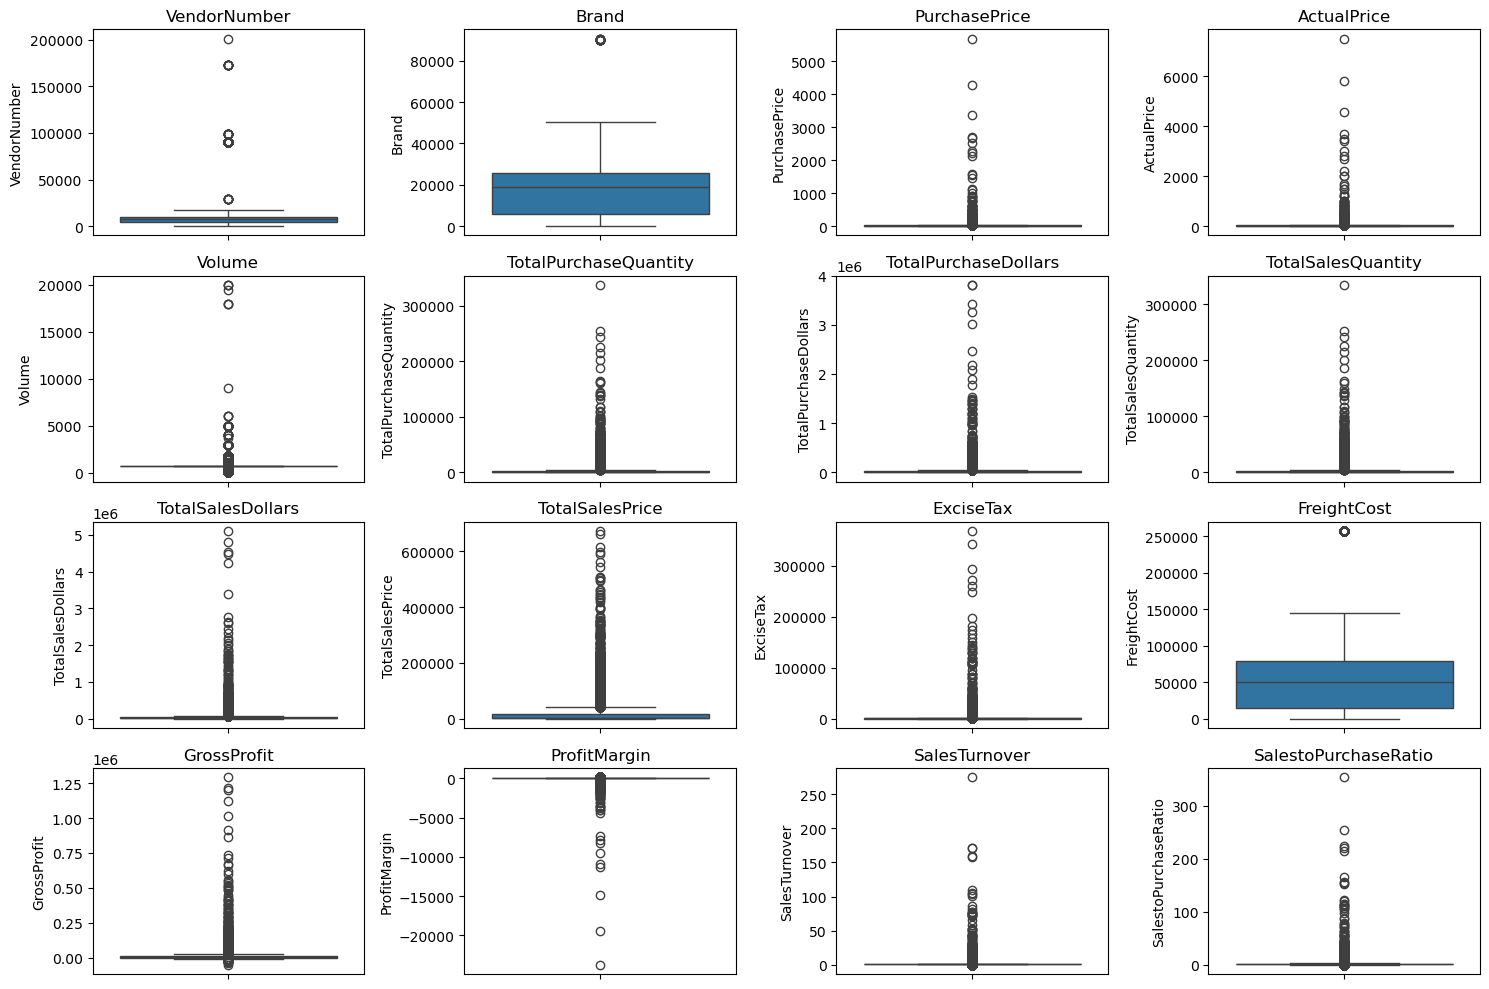

In [99]:
# Outlier detection with box plots 

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show


### Summary Statistics Insights

#### Negative & Zero Values
- **Gross Profit = -5,202.78**, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.  
- **Profit Margin: minimum = -∞**, which suggests cases where revenue is zero or even lower than costs.  
- **Total Sales Quantity & Sales Dollars: minimum = 0**, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

---

#### Outliers Indicated by High Standard Deviations
- **Purchase & Actual Prices**: max values (5,681.81 and 7,499.99) are significantly higher than the mean (24.39 and 3.56A), indicating potential premium products or data entry errors.  
- **Freight Cost**: huge variation from 0.09 to 257,032.07, suggesting logistics inefficiencies or bulk shipments.  
- **Stock Turn**: ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Values greater than 1 indicate the product is sold more than purchased quantity, possibly because sales are being fulfilled from other stock.


In [100]:
# Filtering the data by removing inconsistencies 
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0 """,conn)

In [101]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,ExciseTax,FreightCost,GrossProfit,ProfitMargin,SalesTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


<function matplotlib.pyplot.show(close=None, block=None)>

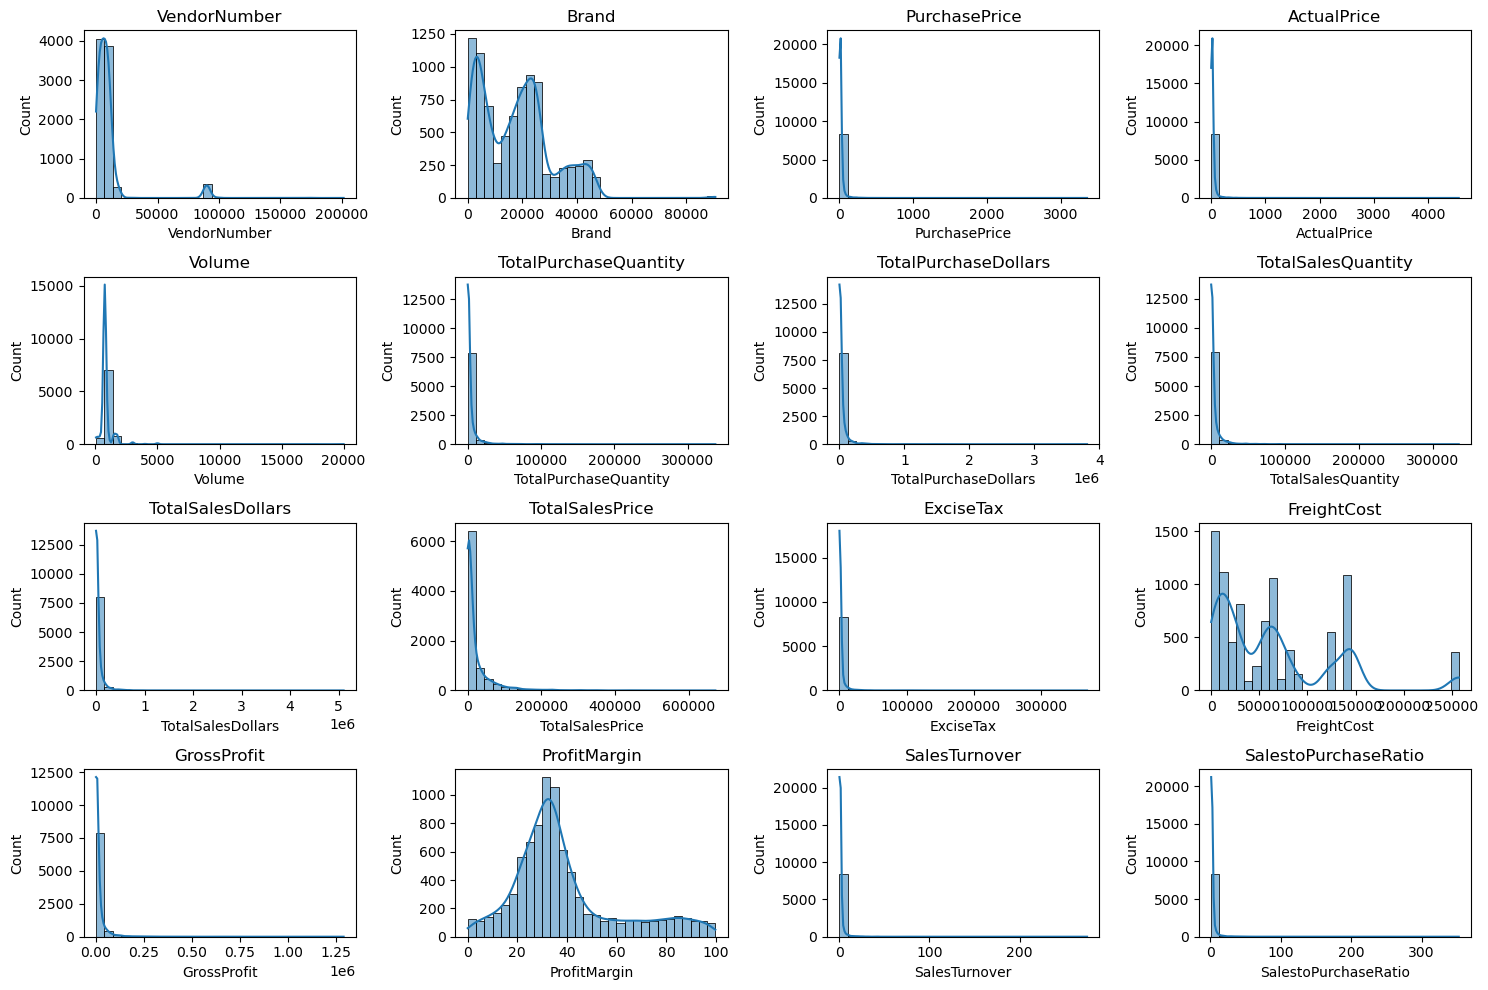

In [102]:
# Distribution Columns for Numerical Columns after cleaning

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)   # Adjust layout as needed
    sns.histplot(df[col],kde=True , bins=30)
    plt.title(col)
plt.tight_layout()
plt.show

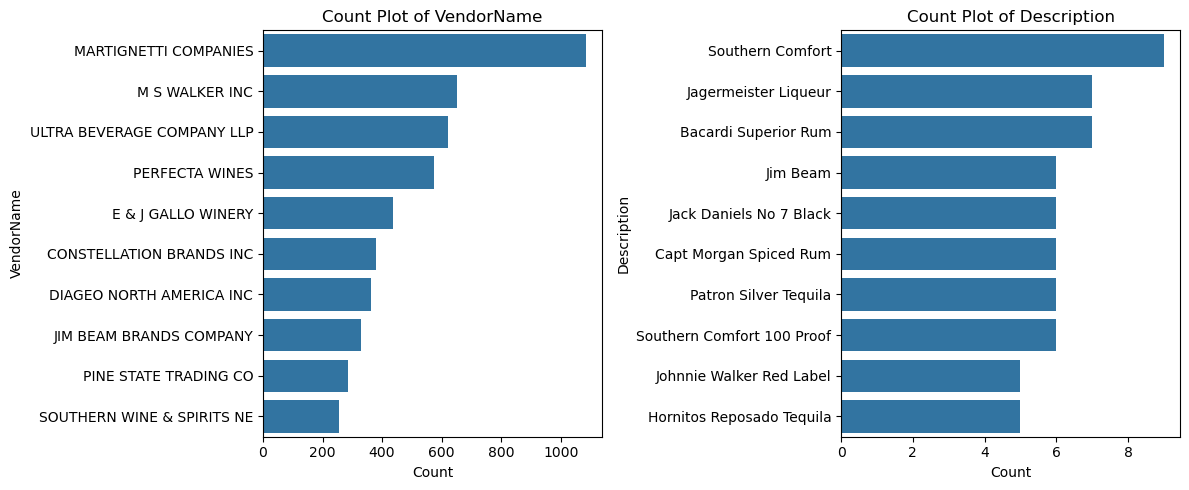

In [103]:
# count plot for categrical columns 
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['VendorName', 'Description']

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    top10 = df[col].value_counts().index[:10]
    sns.countplot(y=col, data=df, order=top10)
    plt.title(f"Count Plot of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

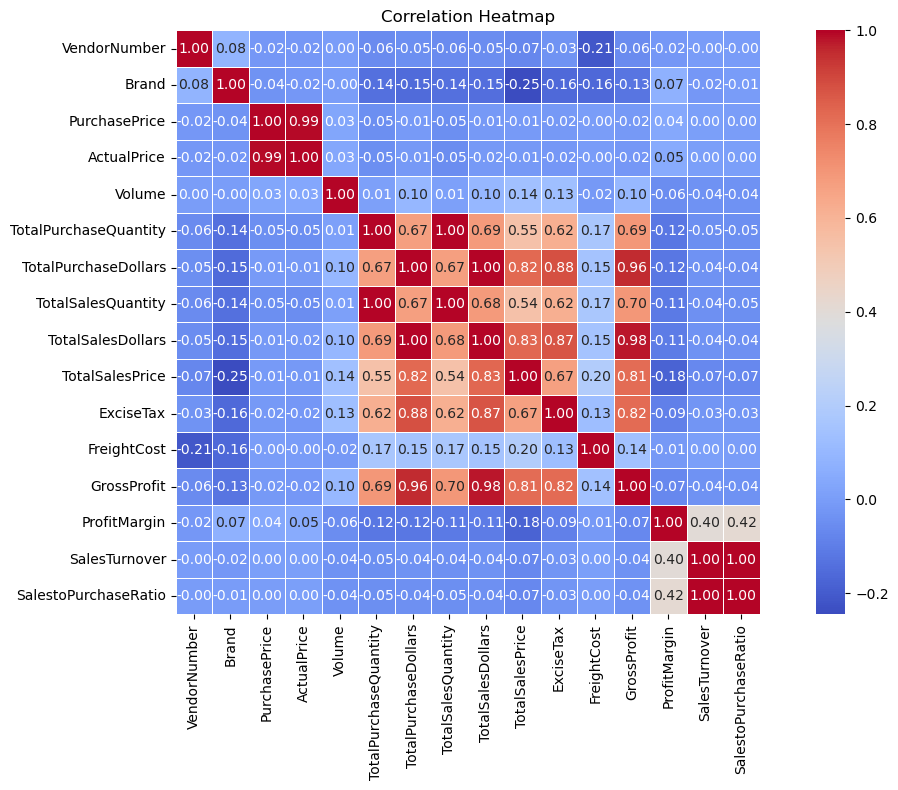

In [104]:
# correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Correlation Insights

- PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.  
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.  
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.  
- StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.


## Data Analysis
 Identify the Brands that need Pricing or Pricing adjustment which exibits lower sales performace but higher profit margin

In [105]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [106]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [107]:
low_sales_threshold

np.float64(560.299)

In [108]:
high_margin_threshold

np.float64(64.97017552750113)

In [109]:
# Filtering brand with low sales but high profit margin 
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold)&
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with low sales but high profit margin:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margin:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


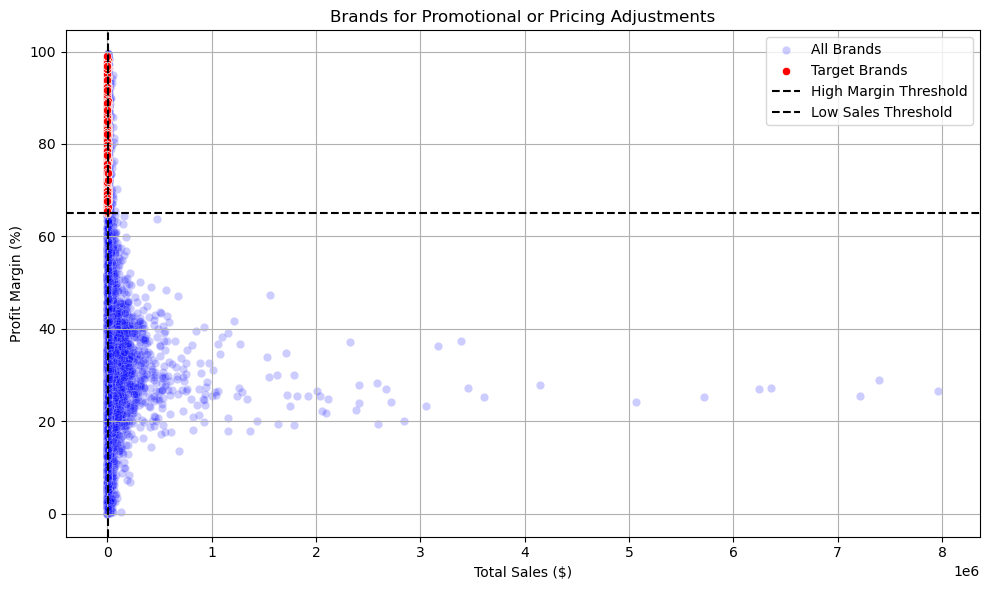

In [110]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="blue",
    label="All Brands",
    alpha=0.2
)
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="red",
    label="Target Brands",
    edgecolor='w',
    linewidth=0.5
)

# Reference lines: horizontal for margin, vertical for sales
plt.axhline(y=high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(x=low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [111]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000]  # for better visulisation 

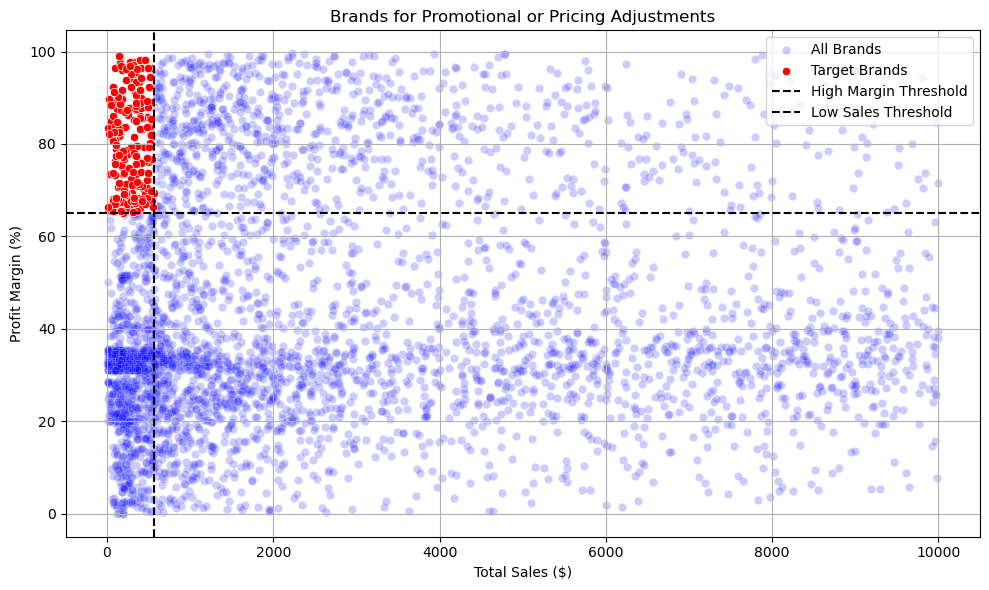

In [112]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="blue",
    label="All Brands",
    alpha=0.2
)
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color="red",
    label="Target Brands",
    edgecolor='w',
    linewidth=0.5
)

# Reference lines: horizontal for margin, vertical for sales
plt.axhline(y=high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(x=low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Which Vendors and Brands represent the higest sales performace ?

In [113]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [114]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

print("Top 10 Vendors by Total Sales:")
print(top_vendors)

print("\nTop 10 Brands by Total Sales:")
print(top_brands)

Top 10 Vendors by Total Sales:
VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

Top 10 Brands by Total Sales:
Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64


In [115]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

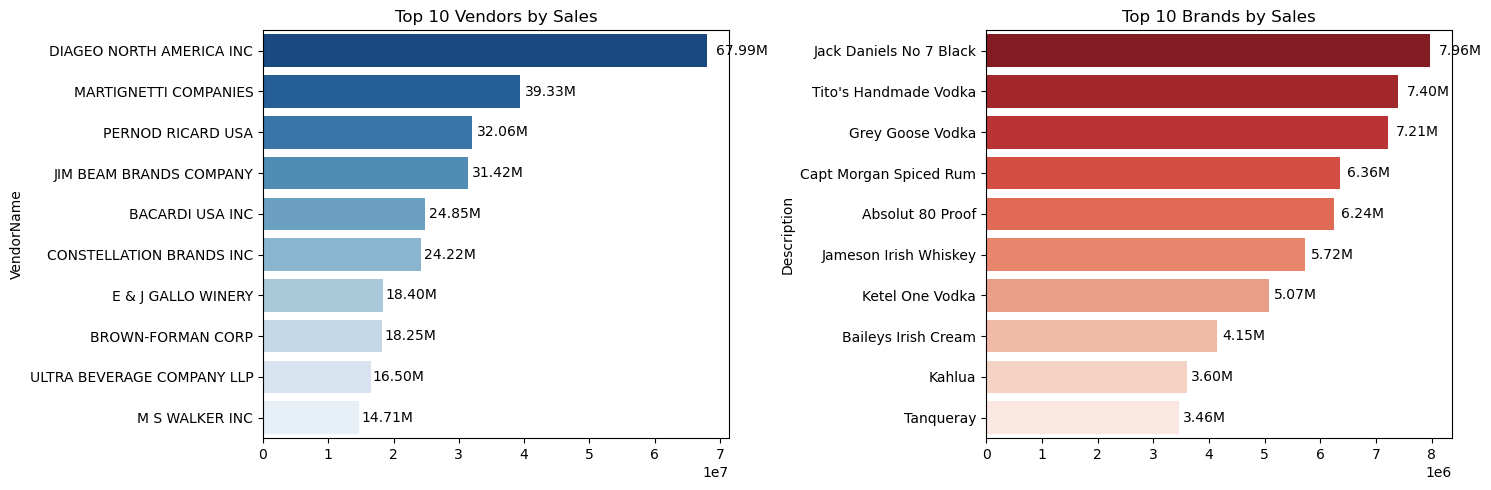

In [116]:
plt.figure(figsize=(15,5))

# PLot for top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot( x= top_vendors.values, y= top_vendors.index, palette ="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
ax2 = plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
ax2.set_title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

<!-- ### Which Vendor contributes the most to the total sales  -->

##### Which Vendor contributes the most to total purcahse dollars ?

In [117]:
vendor_performance =df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [118]:
vendor_performance['Purchase_Contribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [119]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000145
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.008362
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.003809
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000304
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.033981
...,...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13,0.013892
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83,0.097097
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20,1.912074
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28,1.693183


In [120]:
vendor_performance = round(vendor_performance.sort_values('Purchase_Contribution%',ascending=False),2)

In [121]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [122]:
top_vendors['Purchase_Contribution%'].sum()

np.float64(65.69000000000001)

In [123]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


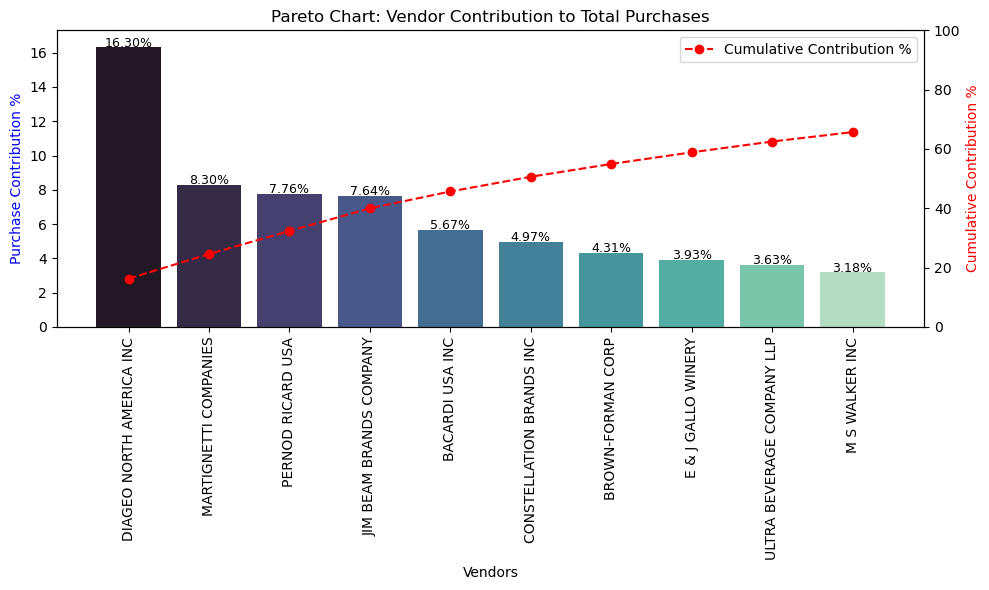

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(x=top_vendors['VendorName'], 
            y=top_vendors['Purchase_Contribution%'], 
            palette="mako", ax=ax1)

# Add bar labels slightly above each bar
for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value + 0.05, f"{value:.2f}%", ha='center', fontsize=9, color='black')

# Line Plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], 
         top_vendors['Cumulative_Contribution%'], 
         color='red', marker='o', linestyle='dashed', label='Cumulative Contribution %')

# Fix x-axis labels
ax1.set_xticks(range(len(top_vendors['VendorName'])))
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

# Axis labels and title
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# Rescale y-axes for better visibility
ax1.set_ylim(0, top_vendors['Purchase_Contribution%'].max() + 1)
ax2.set_ylim(0, 100)   # cumulative contribution should go to 100%

# Horizontal line at 100%
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

# Legend
lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

### How much of total procurment is dependant on the top 10 vendors ?

In [125]:
print(f"Total Contribution of the top 10 vendors is {round( top_vendors['Purchase_Contribution%'].sum(),2)}%")

Total Contribution of the top 10 vendors is 65.69%


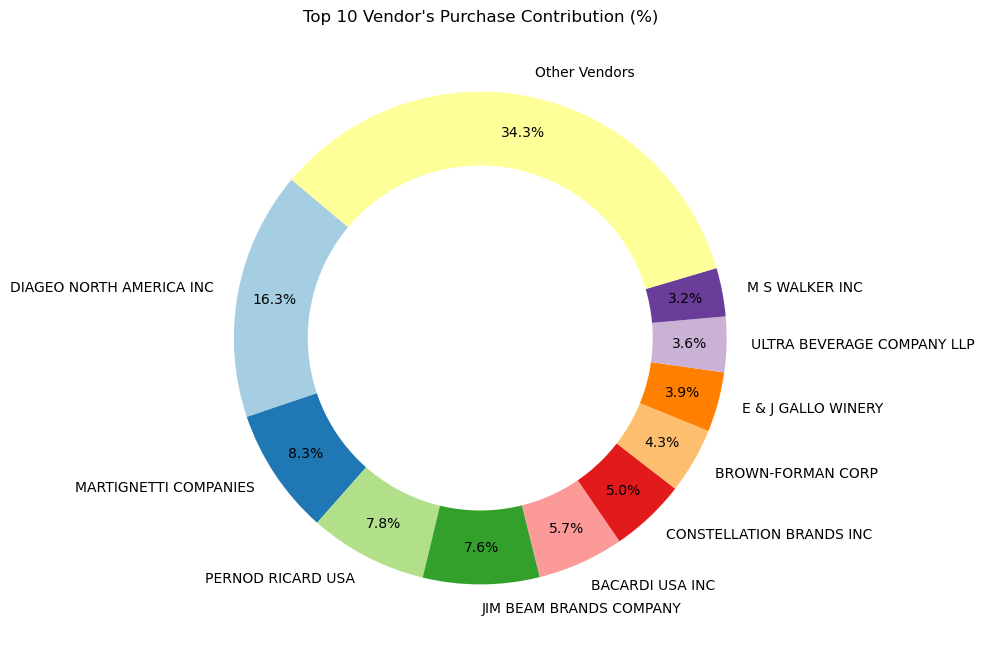

In [126]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


##  Key Insights

### 1. **Highly Concentrated Vendor Influence**
- **DIAGEO NORTH AMERICA INC** alone accounts for **16.3%** of total purchases — the largest single share.
- The top 3 vendors (DIAGEO, MARTIGNETTI, PERNOD RICARD) together contribute over **32%**, indicating a strong reliance on a few dominant suppliers.

### 2. **Long Tail of Smaller Vendors**
- **"Other Vendors"** make up **34.3%**, suggesting a wide base of smaller suppliers.
- This could reflect niche sourcing, regional diversity, or fragmented purchasing for specialized products.

### 3. **Strategic Vendor Relationships**
- Vendors like **JIM BEAM**, **BACARDI**, and **CONSTELLATION BRANDS** each contribute between **5–8%**, showing they’re significant but not dominant.
- These mid-tier suppliers may offer leverage for negotiation or diversification.

---

## Business Implications

- **Risk Management**: Heavy reliance on top vendors could pose supply chain risks. Diversifying or securing long-term contracts may be wise.
- **Negotiation Power**: High-volume vendors may offer better pricing or terms — but also hold more influence.
- **Opportunity Areas**: Smaller vendors (in the "Other" category) might be explored for innovation, local sourcing, or cost savings.


### Does purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost saving ?

In [127]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']


In [128]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,ExciseTax,FreightCost,GrossProfit,ProfitMargin,SalesTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [129]:
df['OrderSize']= pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [130]:
df['OrderSize']

0       Large
1       Large
2       Large
3       Large
4       Large
        ...  
8559    Small
8560    Small
8561    Small
8562    Small
8563    Small
Name: OrderSize, Length: 8564, dtype: category
Categories (3, object): ['Small' < 'Medium' < 'Large']

In [131]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


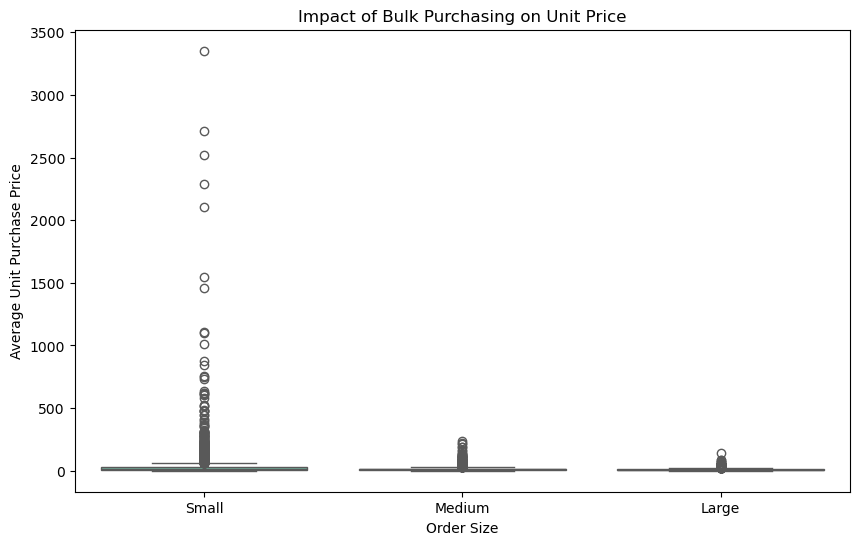

In [132]:
# Set the figure size to 10 inches wide and 6 inches tall
plt.figure(figsize=(10, 6))

# Create a boxplot showing distribution of UnitPurchasePrice across OrderSize categories
# 'data=df' specifies the DataFrame
# 'x="OrderSize"' sets the categorical variable on the x-axis
# 'y="UnitPurchasePrice"' sets the numeric variable on the y-axis
# 'palette="Set2"' applies a pastel color scheme


sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")

# Add a title to the plot
plt.title("Impact of Bulk Purchasing on Unit Price")

# Label the x-axis
plt.xlabel("Order Size")

# Label the y-axis
plt.ylabel("Average Unit Purchase Price")

# Display the plot
plt.show()



- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.  
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost).  
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.  




##  Key Observations

### 1. **Smaller Orders Have Higher Price Variability**
- The **"Small" Order Size** category shows a **wide spread** in unit prices.
- There are **many outliers**, some reaching up to **3300**, suggesting inconsistent pricing for small purchases.
- This could indicate less negotiation power or more frequent one-off purchases.

### 2. **Bulk Purchasing Reduces Unit Price**
- Both **"Medium"** and **"Large"** order sizes have **lower median unit prices** compared to "Small".
- The boxes (IQR) are **narrower**, indicating more consistent pricing.
- This supports the idea that **buying in bulk leads to cost efficiency**.

### 3. **Outlier Behavior**
- Outliers are **much more frequent** in the "Small" category.
- "Medium" and "Large" have **fewer or no extreme outliers**, suggesting more standardized pricing practices.

---

##  Business Implications
- **Encourage bulk purchasing** to stabilize and reduce unit costs.
- **Review pricing strategy** for small orders — consider minimum order thresholds or bundled pricing.
- **Segment customers** by order size to tailor pricing and incentives.



Which Vendors have low inventory turnover, indicating excess stock and slow moving product ?

In [134]:
# Column name should be StockTurnover NOT SalesTurnover
df.rename(columns={'SalesTurnover': 'StockTurnover'}, inplace=True)


In [137]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569



###  Key Observations

- **Low Stock Turnover Values**: All vendors listed have stock turnover ratios below 1.0, which typically indicates **slow inventory movement**. This means products are not being sold or replaced quickly, potentially leading to higher holding costs or outdated stock.

- **Ranking by Efficiency**: The vendors are sorted in ascending order of turnover, so:
  - **ALISA CARR BEVERAGES** has the **lowest turnover** (0.615), suggesting the slowest inventory movement.
  - **WALPOLE MTN VIEW WINERY** has the **highest turnover** in this list (0.820), indicating relatively better inventory flow.

- **Operational Implications**:
  - Vendors with **higher turnover** (closer to 1.0) may be managing inventory more efficiently, possibly due to better demand forecasting, faster sales cycles, or leaner stock levels.
  - Vendors with **lower turnover** might need to investigate issues like overstocking, poor sales performance, or supply chain delays.



## How much capital is tied up in unslod inventory ?

In [144]:
# Total Unsold Inventory Value across all Vendors 
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity'])*df['PurchasePrice']

print('Total Unsold Capital',format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital 2.71M


In [147]:
# Unsold Inventory Capital per Vendor
inventrory_value_per_vendor = df.groupby("VendorName")['UnsoldInventoryValue'].sum().reset_index()
inventrory_value_per_vendor

,VendorName,UnsoldInventoryValue
0,ADAMBA IMPORTS INTL INC,-91.52
1,ALISA CARR BEVERAGES,-43151.48
2,ALTAMAR BRANDS LLC,464.23
3,AMERICAN SPIRITS EXCHANGE,116.76
4,AMERICAN VINTAGE BEVERAGE,3672.17
...,...,...
114,WEIN BAUER INC,1732.03
115,WESTERN SPIRITS BEVERAGE CO,-949.61
116,WILLIAM GRANT & SONS INC,401960.83
117,WINE GROUP INC,86862.57


In [157]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


## What is the 95% confidence interval for the profit margins of top-performing and bottom-performing vendors

In [158]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [159]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [163]:

top_vendors

low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [164]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: 30.74, 31.61, Mean: 31.18
Low Vendors 95% CI: 40.50, 42.64, Mean: 41.57


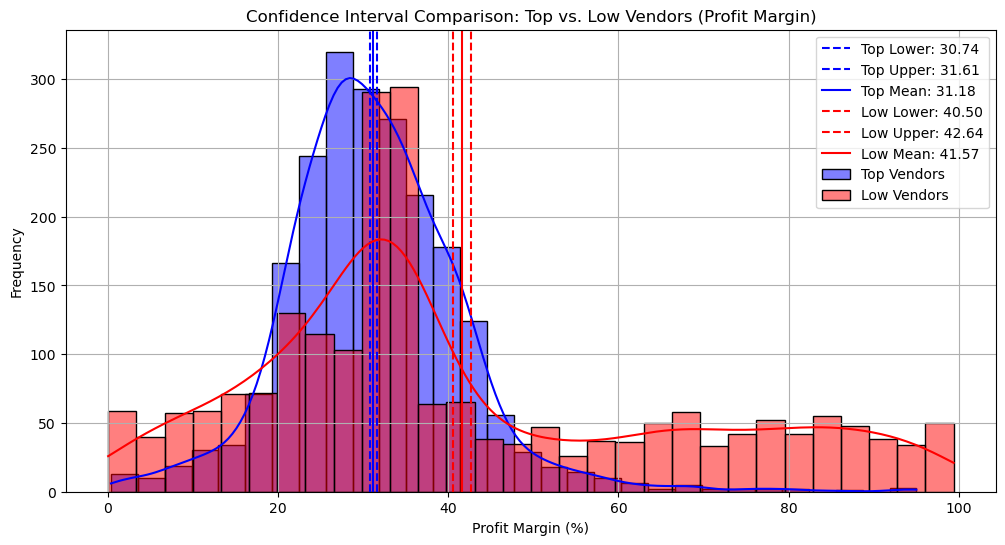

In [165]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: {top_lower:.2f}, {top_upper:.2f}, Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: {low_lower:.2f}, {low_upper:.2f}, Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


###  Key Observations from the Graph

#### 1. **Profit Margin Distributions**
- **Top Vendors (Blue)**:
  - Mean Profit Margin: **31.18%**
  - 95% Confidence Interval: **30.74% to 31.61%**
- **Low Vendors (Red)**:
  - Mean Profit Margin: **41.57%**
  - 95% Confidence Interval: **40.50% to 42.64%**

This shows that **low-performing vendors have significantly higher profit margins** than top-performing ones.


###  What This Suggests

####  **Inverse Relationship Between Sales and Margin**
- Vendors with **lower total sales** tend to have **higher profit margins**.
- Vendors with **higher total sales** operate on **thinner margins** — possibly due to volume-based pricing, competitive pressure, or economies of scale.

#### **Statistical Significance**
- The confidence intervals **do not overlap**, which strongly suggests the difference in means is **statistically significant**.
- This means the observed difference is unlikely due to random chance.

####  **Distribution Shape**
- Both groups show smooth KDE curves, indicating reasonably normal distributions.
- The top vendors’ distribution is tighter (narrower CI), suggesting **less variability** in their profit margins.
- Low vendors show a slightly wider spread, indicating **more variability**.

---

###  Strategic Implications

- **High-margin, low-volume vendors** might be niche or premium sellers.
- **Low-margin, high-volume vendors** could be mainstream or discount-driven.
- This insight could guide pricing strategy, vendor segmentation, or performance benchmarking.



##  Hypothesis Test: Profit Margin Comparison

**Question:**  
Is there a significant difference in profit margins between top-performing and low-performing vendors?

### Hypotheses

- **H₀ (Null Hypothesis):**  
  There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

- **H₁ (Alternative Hypothesis):**  
  The mean profit margins of top-performing and low-performing vendors are significantly different.}

In [171]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.


In [172]:
df.to_csv("vendors_data.csv", index=False)
